[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/00_simulation.ipynb)

# 00 — Generate the simulation data



**Purpose.** Run the three simulation stages end to end and explain what each

one does, so the files everything downstream reads are reproducible from this

notebook alone.



**Inputs.** `configs/simulation.yaml` — every path and every setting comes from

there. Nothing is hard-coded here.



**Outputs.**


| stage | writes |
|---|---|
| scenario | `data/external/ue_positions.csv`, `data/external/scenario.json` |
| radio map | `data/interim/radio_map.npz` |
| MDT | `data/interim/mdt.csv`, `data/interim/demand_map.npz` |


**Before you run.** The radio map and the MDT stages need a CUDA GPU and the

Sionna-RT extra (`task sync:rt`). The radio map stage is the slow one — it traces

rays for every transmitter on every band, and how long that takes depends on the

fidelity settings in the config.



The equivalent from a shell is `task simulation`, which runs the same three

stages in the same order.

## 0. Environment



Run this section first, wherever you are.



**Locally** it only walks up to the project root and makes it the working

directory, so the root-relative paths in `configs/simulation.yaml` resolve the

same way they do for `task simulation`. Nothing is installed.



**In Colab** it also clones the repository, puts it on `sys.path` so `import src`

works without an editable install, and installs the packages Colab does not

already ship. Note that `data/` is DVC-tracked and therefore *not* part of the

clone.

In [1]:
# --- Environment bootstrap -------------------------------------------------

REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"

BRANCH = "main"

SUBDIR = "."  # project root inside the repository



# (import name, pip name). Colab already ships numpy, pandas, matplotlib and

# seaborn, so only these are installed.

COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna", "sionna-rt")]



import importlib.util

import os

import subprocess

import sys

from pathlib import Path



try:

    import google.colab  # noqa: F401



    IN_COLAB = True

except ImportError:

    IN_COLAB = False



if IN_COLAB:

    checkout = Path("/content") / Path(REPO_URL).stem

    if not checkout.exists():

        subprocess.run(

            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],

            check=True,

        )

    root = (checkout / SUBDIR).resolve()

    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]

    if missing:

        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

else:

    # JupyterLab starts the kernel in notebooks/; walk up to the project root.

    root = Path.cwd()

    while not (root / "pyproject.toml").exists() and root != root.parent:

        root = root.parent



os.chdir(root)

if str(root) not in sys.path:

    sys.path.insert(0, str(root))  # makes `import src` work without an editable install



# Extra Hydra overrides consumed by load_config() in section 1.

CONFIG_OVERRIDES: list[str] = []



print(f"project root: {root}   colab: {IN_COLAB}")

project root: d:\Projects\band-tilt   colab: False


## 1. Setup



Compose the config and seed everything. Every notebook starts the same way, so

that a cell copied between notebooks behaves identically.

In [2]:
%load_ext autoreload
%autoreload 2

from functools import partial

import pandas as pd

from src.config import load_config
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()

# Figures land here so they can be viewed without rerunning the notebook; skipped on Colab.
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/00_simulation"))

pd.set_option("display.max_columns", 50)
cfg.simulation.output

{'ue_file': 'data/external/ue_positions.csv', 'manifest_file': 'data/external/scenario.json', 'radio_map_file': 'data/interim/radio_map.npz', 'mdt_file': 'data/interim/mdt.csv', 'demand_map_file': 'data/interim/demand_map.npz'}

In [3]:
import dataclasses
import json
import math
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Every render in this notebook looks straight down. A square resolution frames
# the scene the same way whichever axis mitsuba measures the field of view on.
RENDER_FOV = 45.0
RENDER_RESOLUTION = (900, 900)
RENDER_SAMPLES = 128


def top_down_camera(bounds, centre=None, span=None, margin=1.08):
    """Build a camera above ``centre`` looking straight down.

    Args:
        bounds: Scene extent, used for the default framing and the ground height.
        centre: ``(x, y)`` to look at. Defaults to the centre of ``bounds``.
        span: Ground width to cover in metres. Defaults to the longer side.
        margin: Slack left around ``span``.
    """
    from sionna.rt import Camera

    if centre is None:
        centre = (0.5 * (bounds.min_x + bounds.max_x), 0.5 * (bounds.min_y + bounds.max_y))
    if span is None:
        span = max(bounds.width_m, bounds.depth_m)
    height = bounds.max_z + 0.5 * span * margin / math.tan(math.radians(0.5 * RENDER_FOV))
    return Camera(
        position=[float(centre[0]), float(centre[1]), float(height)],
        look_at=[float(centre[0]), float(centre[1]), float(bounds.min_z)],
    )


def render(scene, camera, title, name=None, **kwargs):
    """Render ``scene`` at the shared fidelity, title it, save it under ``name`` if given, and show it."""
    figure = scene.render(
        camera=camera,
        fov=RENDER_FOV,
        resolution=RENDER_RESOLUTION,
        num_samples=RENDER_SAMPLES,
        **kwargs,
    )
    figure.axes[0].set_title(title)
    figure.tight_layout()  # sionna lays the figure out before the title exists
    if name is not None:
        save_fig(figure, name)
    plt.show()

## 2. The node layout — a one-off, not part of a run

Before any of this can run, the config needs a table of cells: where each mast
stands, which way it points, and what tilt it starts at on each band.

That table is generated once, by `task simulation:layout`, and pasted into
`configs/simulation.yaml` under `transmitters.cells`. The generator lays nodes
out on a square lattice about the middle of the scene, then walks outward from
each ideal position until it finds a tile that is open ground with an open
surround, confirms that tile with a downward ray, and stands the mast a fixed
height above the ground it measured. A node with no such tile within reach makes
the generator fail rather than putting a mast on a roof.

It is deliberately not re-run here. The masts are surveyed against the city
once and then held fixed, as a real mast stays where it was built.

In [4]:
from src.simulation import transmitter

cells = transmitter.load(cfg)

pd.DataFrame(
    [
        {
            "name": cell.name,
            "x": cell.x,
            "y": cell.y,
            "z": cell.z,
            "azimuth_deg": cell.azimuth_deg,
            **{f"tilt_{band}": cell.tilt_for(band).baseline_deg for band in cell.tilt},
        }
        for cell in cells
    ]
)

,name,x,y,z,azimuth_deg,tilt_b2600,tilt_b1800,tilt_b700
0,n0c0,-380.34,-489.80,30.0,0.0,8.0,6.0,4.0
1,n0c1,-380.34,-489.80,30.0,120.0,8.0,6.0,4.0
2,n0c2,-380.34,-489.80,30.0,240.0,8.0,6.0,4.0
3,n1c0,-465.72,352.86,30.0,0.0,8.0,6.0,4.0
4,n1c1,-465.72,352.86,30.0,120.0,8.0,6.0,4.0
5,n1c2,-465.72,352.86,30.0,240.0,8.0,6.0,4.0
6,n2c0,257.15,-470.78,30.0,0.0,8.0,6.0,4.0
7,n2c1,257.15,-470.78,30.0,120.0,8.0,6.0,4.0
8,n2c2,257.15,-470.78,30.0,240.0,8.0,6.0,4.0
9,n3c0,192.83,229.83,30.0,0.0,8.0,6.0,4.0


## 3. Stage 1 — the scenario

A scenario is the city together with the people in it. It is drawn once and
then held fixed, so that later stages can change tilt with nothing else moving
underneath. That is what makes the KPIs a function of tilt.

What the stage does, in order:

1. **Load the scene.** The city geometry ships with Sionna-RT.
2. **Raster the scene.** A square grid is laid over it and rays are cast
   straight down inside every tile, which says how much of the tile is open
   ground and how tall whatever stands there is.
3. **Place the demand hotspots.** Their centres are drawn towards densely built
   areas, because that is both where users gather and where propagation is
   hardest. That tension is the problem the project is about.
4. **Build the time schedule.** Demand rises and falls across the day and
   carries over from one interval to the next, so load has structure rather than
   being noise a configuration cannot be tuned against.
5. **Draw the UEs.** Each interval gets a fresh crowd, drawn from the hotspots
   and from a uniform background, with every position checked to be on open
   ground and inside the region of interest.

It writes the UE table and a manifest that records what this scenario is, so it
can be regenerated and so the train/validation/test split can be made between
whole scenarios.

In [5]:
from src.simulation import scenario



ue_file, manifest_file = scenario.generate(cfg)

jitc_llvm_init(): LLVM API initialization failed ..


scenario: scn_d2842dfd53c19e82
grid:     74 x 61 tiles, 4333 eligible
hotspots: 4
time:     168 intervals of 3600 s, 40-80 UEs each
demand:   hotspots hold 79% to 94% of the population across intervals
ue:       9939 rows at z=1.5 m
densest decile holds 58.3% of UEs
csv:      data\external\ue_positions.csv
manifest: data\external\scenario.json


In [6]:
manifest = json.loads(Path(manifest_file).read_text(encoding="utf-8"))

pd.DataFrame(
    {
        "value": {
            "scenario_id": manifest["scenario_id"],
            "seed": manifest["seed"],
            **manifest["grid"],
            "n_intervals": manifest["time"]["n_intervals"],
            "ue_rows": manifest["ue"]["rows"],
        }
    }
)

,value
scenario_id,scn_d2842dfd53c19e82
seed,42
launch_z,108.57
n_cols,74
n_rows,61
origin_x,-805.583679
origin_y,-688.600647
tile_size_m,20.0
n_intervals,168
ue_rows,9939


In [7]:
pd.DataFrame(manifest["density"]["hotspots"])

,rotation_rad,sigma_major_m,sigma_minor_m,x,y
0,1.319400,150.457166,57.976418,489.452166,56.673197
1,0.875041,134.123766,116.425166,72.254354,-343.027986
2,2.633298,130.639949,40.326218,-239.405204,-369.565567
3,2.962107,144.215391,78.839084,-6.681146,183.262837


In [8]:
ue = pd.read_csv(ue_file)

print(f"{len(ue):,} rows x {ue.shape[1]} columns")
print(ue.dtypes.to_string())
ue.head()

9,939 rows x 8 columns
t_index        int64
t_s          float64
x            float64
y            float64
z            float64
tile_col       int64
tile_row       int64
component      int64


,t_index,t_s,x,y,z,tile_col,tile_row,component
0,0,0.0,-622.634,-421.740,1.5,9,13,-1
1,0,0.0,562.812,76.556,1.5,68,38,0
2,0,0.0,26.025,-367.147,1.5,41,16,1
3,0,0.0,25.772,322.195,1.5,41,50,3
4,0,0.0,399.227,-280.717,1.5,60,20,0


In [9]:
ue.describe().T

,count,mean,std,min,25%,50%,75%,max
t_index,9939.0,82.744542,48.259498,0.000,41.0000,81.000,126.0000,167.000
t_s,9939.0,297880.350136,173734.191398,0.000,147600.0000,291600.000,453600.0000,601200.000
x,9939.0,30.892832,301.503110,-804.271,-184.5435,9.723,201.0885,669.525
y,9939.0,-141.105323,292.135493,-687.554,-380.6205,-231.857,136.1710,516.800
z,9939.0,1.500000,0.000000,1.500,1.5000,1.500,1.5000,1.500
tile_col,9939.0,41.321260,15.073047,0.000,31.0000,40.000,50.0000,73.000
tile_row,9939.0,26.875138,14.601502,0.000,15.0000,22.000,41.0000,60.000
component,9939.0,1.294195,1.306815,-1.000,0.0000,1.000,2.0000,3.000


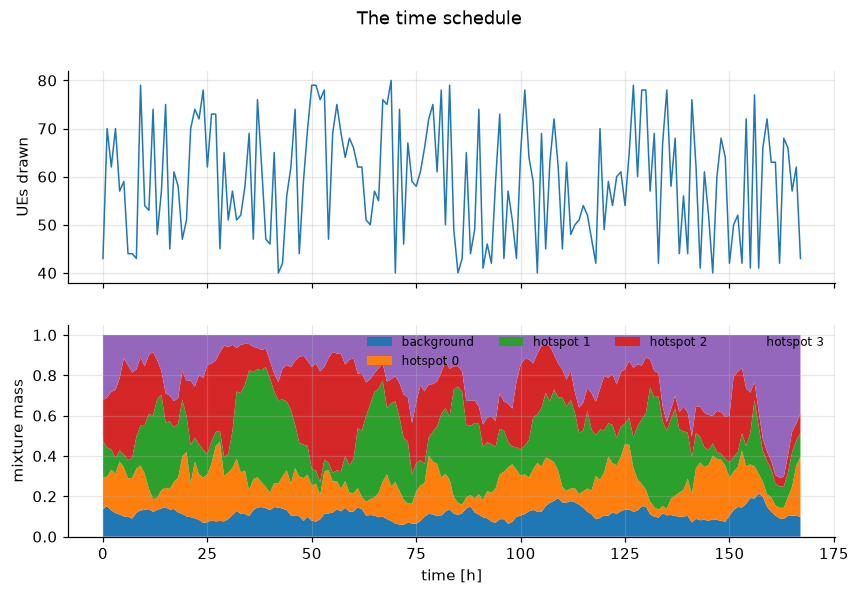

In [10]:
hours = np.asarray(manifest["time"]["t_s"]) / 3600.0
mass = np.asarray(manifest["time"]["component_mass"])

figure, axes = plt.subplots(2, 1, figsize=(9.0, 5.5), sharex=True)
axes[0].plot(hours, manifest["time"]["count"], lw=1.0)
axes[0].set_ylabel("UEs drawn")
axes[1].stackplot(
    hours,
    mass.T,
    labels=["background"] + [f"hotspot {index}" for index in range(mass.shape[1] - 1)],
)
axes[1].set_ylabel("mixture mass")
axes[1].set_xlabel("time [h]")
axes[1].legend(loc="upper right", ncol=4, fontsize=8)
figure.suptitle("The time schedule")
save_fig(figure, "time_schedule")
plt.show()

### The scene

Rendered from the same camera every later render in this notebook reuses.

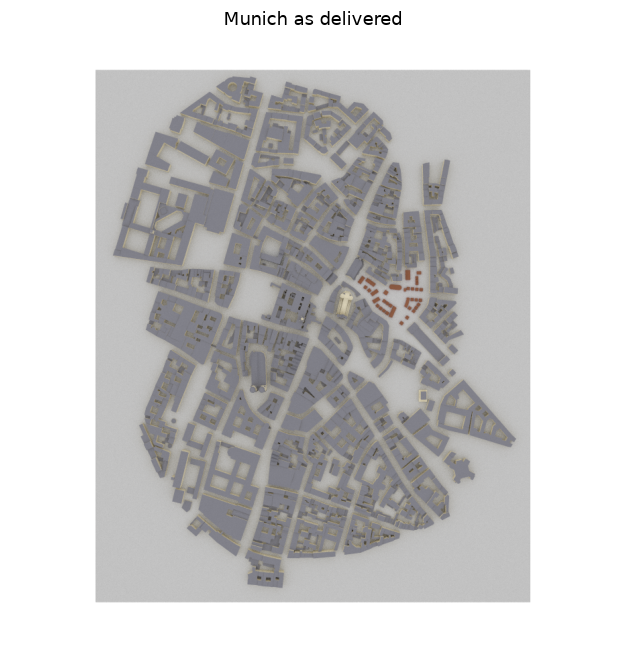

In [11]:
from src.simulation import seeds
from src.simulation import scene as scene_module
from src.simulation.scene import SceneSpec

scene, bounds = scene_module.load(SceneSpec.from_config(cfg))
camera = top_down_camera(bounds)

render(scene, camera, "Munich as delivered", name="scene_delivered")

## 4. Stage 2 — the radio map

The radio map is the ground truth: how strong a signal every grid tile would
receive from every transmitter.

1. **Rebuild the same city.** The scene is loaded again, so it matches the
   scenario exactly.
2. **Install the radio materials.** They are swapped for plain ones fixed at
   their ITU-R P.2040 values for the carrier, which do not recompute themselves
   when the carrier changes. That is what lets the low band be solved at all.
3. **Add the transmitters.** Each cell is placed at the tilt the config gives
   it *for the band being solved*, so two bands on the same mast can point
   differently. That freedom is the thing being optimised.
4. **Solve.** The solver traces rays from every transmitter over the same grid
   the UEs were binned into, and the result is turned into RSRP.

One band at a time, because a scene carries a single carrier frequency. Tiles no
ray reaches are left empty rather than set to zero — no coverage and no
measurement are different things.

In [12]:
from src.simulation import radio



radio_map_file = radio.solve(cfg)

   b2600  tilt  8.0- 8.0 deg     2.1s  tiles reached 100.0%  best server -129.0 to  -53.0 dBm
   b1800  tilt  6.0- 6.0 deg     2.2s  tiles reached 100.0%  best server -115.7 to  -51.8 dBm
    b700  tilt  4.0- 4.0 deg     1.5s  tiles reached 100.0%  best server -110.0 to  -44.4 dBm
radio map: data\interim\radio_map.npz  shape (3, 12, 61, 74) [band, tx, row, col]


In [13]:
with np.load(radio_map_file, allow_pickle=False) as archive:
    radio_map_data = {key: archive[key] for key in archive.files}

pd.DataFrame(
    [
        {"key": key, "shape": str(value.shape), "dtype": str(value.dtype)}
        for key, value in radio_map_data.items()
    ]
)

,key,shape,dtype
0,rsrp_dbm,"(3, 12, 61, 74)",float32
1,sinr_db,"(3, 12, 61, 74)",float32
2,band_hz,"(3,)",float64
3,band_label,"(3,)",<U5
4,tilt_deg,"(3, 12)",float64
5,tx_name,"(12,)",<U4
6,origin_x,(),float64
7,origin_y,(),float64
8,tile_size_m,(),float64
9,n_cols,(),int64


In [14]:
rsrp = radio_map_data["rsrp_dbm"]
sinr = radio_map_data["sinr_db"]
bands = [str(label) for label in radio_map_data["band_label"]]
tx_names = [str(name) for name in radio_map_data["tx_name"]]
n_rows, n_cols = int(radio_map_data["n_rows"]), int(radio_map_data["n_cols"])
tile_size = float(radio_map_data["tile_size_m"])
extent = [
    float(radio_map_data["origin_x"]),
    float(radio_map_data["origin_x"]) + n_cols * tile_size,
    float(radio_map_data["origin_y"]),
    float(radio_map_data["origin_y"]) + n_rows * tile_size,
]

with warnings.catch_warnings():
    # A tile no ray reached is all-NaN, and nanmax over one warns.
    warnings.simplefilter("ignore", RuntimeWarning)
    best_server = np.stack([np.nanmax(rsrp[index], axis=0) for index in range(len(bands))])
    # Per band, the best transmitter's SINR: a description of the map, not a
    # serving decision (that is src/kpi/capacity.py's rule).
    best_sinr = np.stack([np.nanmax(sinr[index], axis=0) for index in range(len(bands))])

pd.DataFrame(
    {
        "cells_reached": np.isfinite(best_server).mean(axis=(1, 2)),
        "rsrp_min": np.nanmin(best_server, axis=(1, 2)),
        "rsrp_median": np.nanmedian(best_server, axis=(1, 2)),
        "rsrp_max": np.nanmax(best_server, axis=(1, 2)),
        "sinr_median": np.nanmedian(best_sinr, axis=(1, 2)),
        "sinr_max": np.nanmax(best_sinr, axis=(1, 2)),
    },
    index=bands,
)


,cells_reached,rsrp_min,rsrp_median,rsrp_max,sinr_median,sinr_max
b2600,1.0,-129.008957,-80.542427,-52.965714,8.870154,44.798763
b1800,1.0,-115.650398,-77.627731,-51.839634,9.346571,45.180828
b700,1.0,-110.025368,-66.569778,-44.429195,10.666542,45.192207


In [15]:
pd.DataFrame(radio_map_data["tilt_deg"].T, index=tx_names, columns=bands)

,b2600,b1800,b700
n0c0,8.0,6.0,4.0
n0c1,8.0,6.0,4.0
n0c2,8.0,6.0,4.0
n1c0,8.0,6.0,4.0
n1c1,8.0,6.0,4.0
n1c2,8.0,6.0,4.0
n2c0,8.0,6.0,4.0
n2c1,8.0,6.0,4.0
n2c2,8.0,6.0,4.0
n3c0,8.0,6.0,4.0


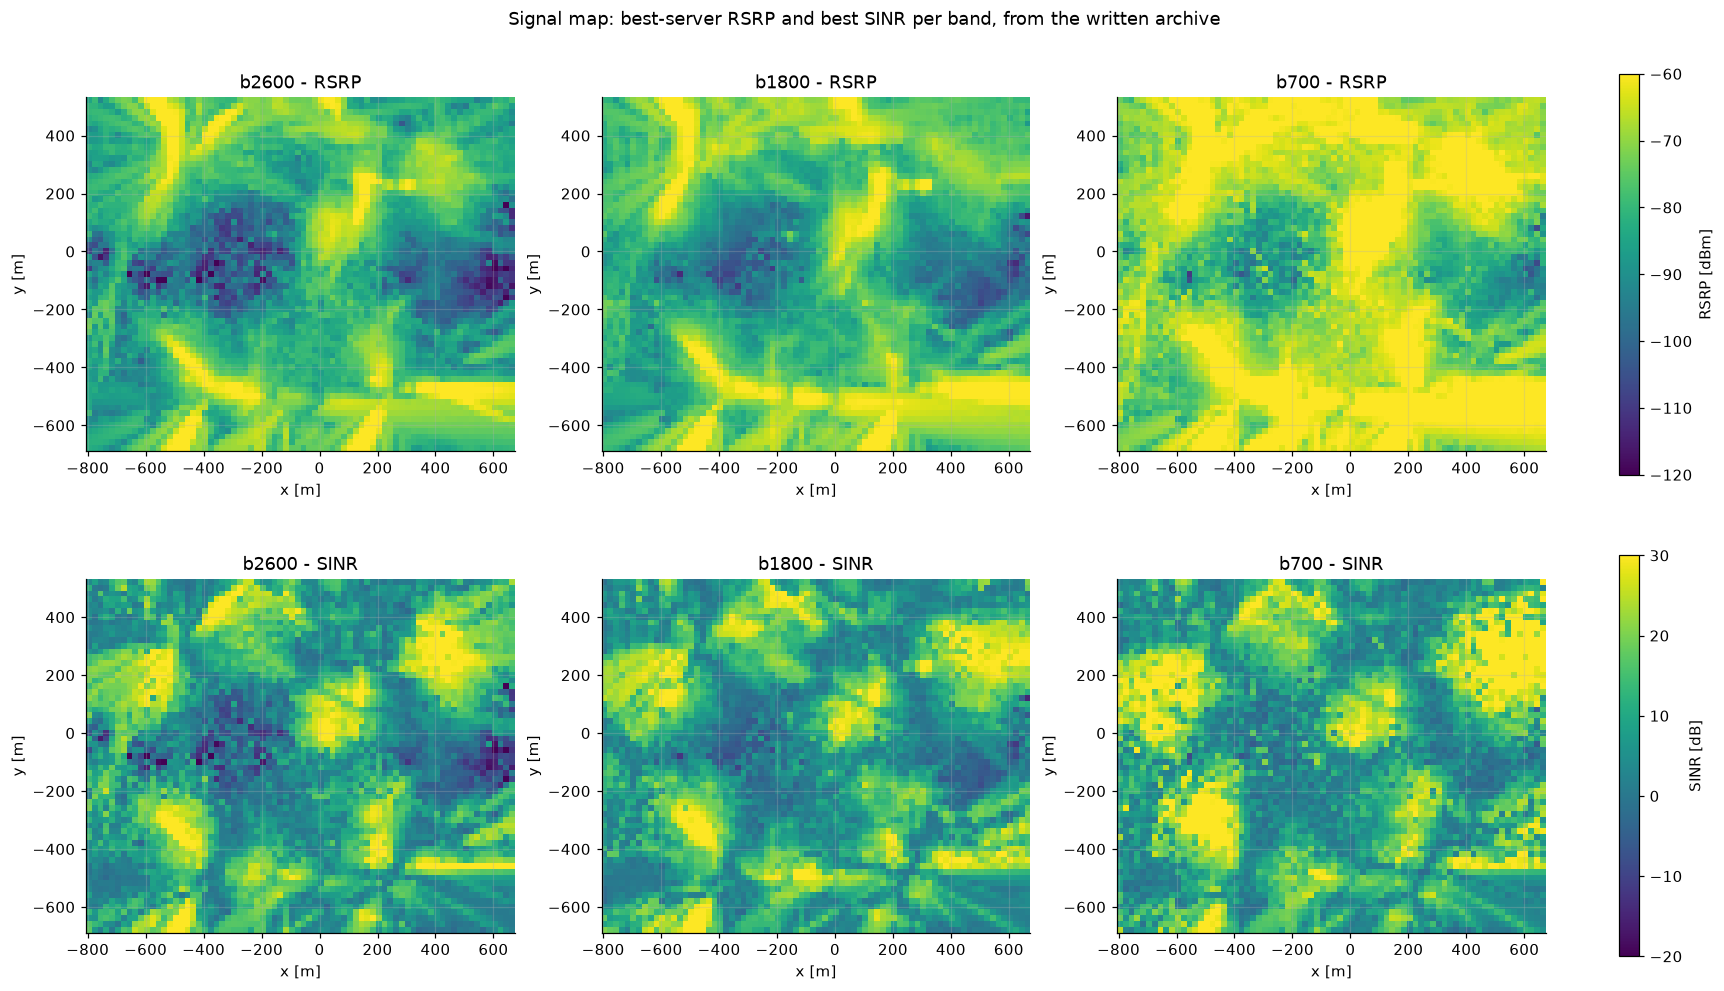

In [16]:
# One scale per row, and the RSRP row shares the limits of the ray-traced views
# below, so the bands compare against each other and against the render. SINR
# is sionna-rt's own: co-band interference at full load plus kTB over the band.
RSRP_LIMITS = (-120.0, -60.0)
SINR_LIMITS = (-20.0, 30.0)

figure, axes = plt.subplots(
    2, len(bands), figsize=(5.2 * len(bands), 9.0), constrained_layout=True, squeeze=False
)
for row, (layers, limits, label) in enumerate(
    [(best_server, RSRP_LIMITS, "RSRP [dBm]"), (best_sinr, SINR_LIMITS, "SINR [dB]")]
):
    for axis, index, band in zip(axes[row], range(len(bands)), bands):
        image = axis.imshow(
            layers[index],
            origin="lower",
            extent=extent,
            aspect="equal",
            vmin=limits[0],
            vmax=limits[1],
        )
        axis.set_title(f"{band} - {label.split()[0]}")
        axis.set_xlabel("x [m]")
        axis.set_ylabel("y [m]")
    figure.colorbar(image, ax=axes[row], label=label, shrink=0.85)
figure.suptitle("Signal map: best-server RSRP and best SINR per band, from the written archive")
save_fig(figure, "radio_map_best_server")
plt.show()


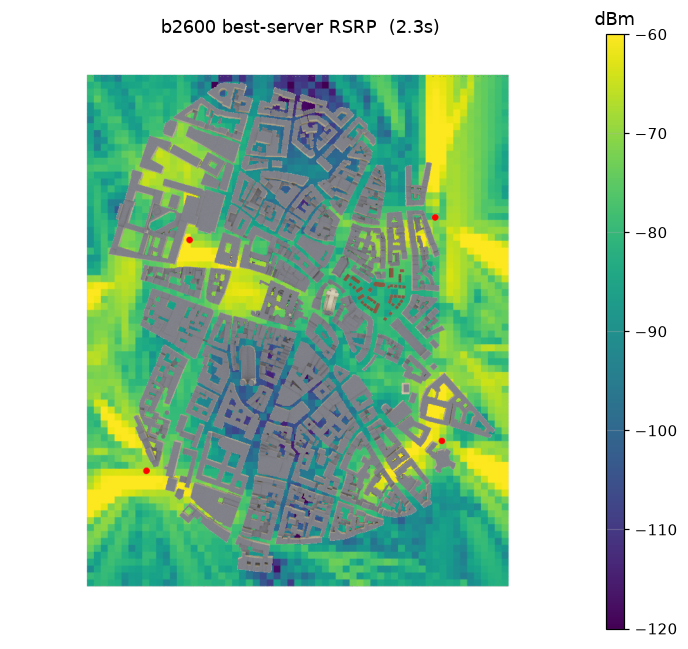

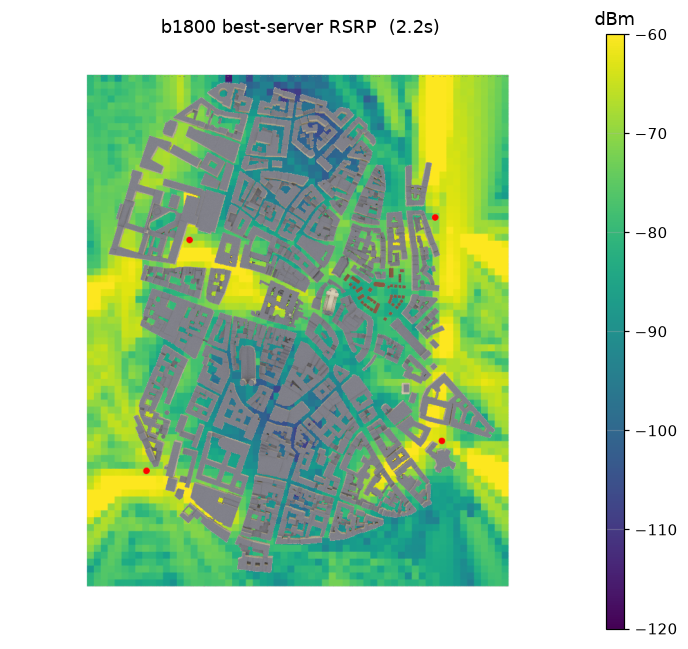

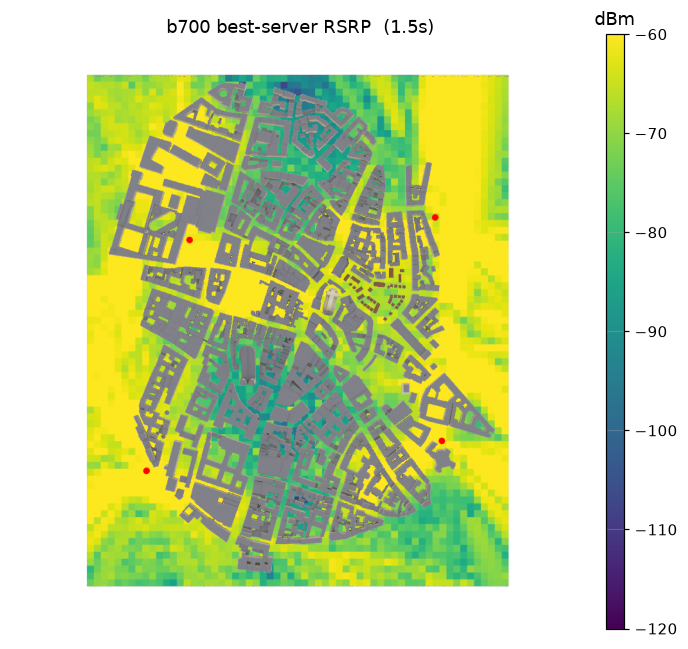

In [17]:
radio.configure_arrays(scene, cfg)
solver_spec = radio.SolverSpec.from_config(cfg)

for entry in cfg.simulation.radio_map.bands:
    band = radio.Band.from_config(entry)
    _, elapsed, _, live_map = radio.solve_band(
        scene,
        cells,
        band,
        solver_spec,
        seeds.stream(cfg, "solver"),
        manifest["grid"],
        float(cfg.simulation.ue.height_m),
        float(cfg.simulation.antenna.power_rs),
    )
    render(
        scene,
        camera,
        f"{band.name} best-server RSRP  ({elapsed:.1f}s)",
        name=f"radio_map_render_{band.name}",
        radio_map=live_map,
        rm_metric="rss",
        rm_vmin=RSRP_LIMITS[0],
        rm_vmax=RSRP_LIMITS[1],
        rm_show_color_bar=True,
    )

## 5. Stage 3 — the MDT and the demand map

MDT is what a handset reports, as opposed to what is true.

1. **Look each UE up in the map.** Its grid tile gives the clean RSRP and SINR
   from every cell-band pair.
2. **Add measurement error.** Independent receiver error on each, with its own
   sigma (`simulation.mdt.rsrp_noise_sigma_db`, `sinr_noise_sigma_db`). The
   shadowing that fading models stand in for is already there, computed from the
   actual buildings, so adding fading on top would count them twice.
3. **Serve each UE from what it reported.** The serving rule in
   `src/kpi/capacity.py` — band preference above an RSRP threshold, under each
   cell-band's `max_prb` — picks a cell-band per UE within its interval.
4. **Turn that into demand.** Every UE is assumed to need
   `kpi.capacity.throughput_per_ue_bps` (40 Mbps), which at its SINR costs
   `40 Mbps / (12 · SCS · log2(1 + SINR))` PRBs. A blocked UE still counts at its
   first choice: this is demand, not what was served. The PRBs per tile per
   interval are the demand map.

Every cell-band with a path is reported; an empty measurement means only that no
ray reached the tile. The clean map from stage 2 is written separately and is
not touched here: it is the label a surrogate learns, and noising a label would
teach a model to predict noise.


In [18]:
from src.simulation import mdt



mdt_file = mdt.build(cfg)

ue:        9939 rows x 36 cell-bands of RSRP and SINR (0 no-signal UEs dropped)
intervals: 168, 59 UEs per interval on average
reachable:  69.2% of measurements had a path
per ue:    9 to 36 cells reported
admitted:   53.4% of UEs fit a cell-band's PRBs
demand:    peak tile 9756.7 PRBs in one interval
mdt:       data\interim\mdt.csv
demand:    data\interim\demand_map.npz  shape (168, 61, 74) [t, row, col]


In [19]:
mdt_frame = pd.read_csv(mdt_file)
measurement_columns = [column for column in mdt_frame.columns if column.startswith("rsrp_")]
sinr_columns = [column for column in mdt_frame.columns if column.startswith("sinr_")]

print(
    f"{len(mdt_frame):,} rows: "
    f"{mdt_frame.shape[1] - len(measurement_columns) - len(sinr_columns)} position "
    f"+ {len(measurement_columns)} RSRP + {len(sinr_columns)} SINR columns"
)
print(f"{len(ue) - len(mdt_frame):,} UEs no transmitter reached were dropped")
mdt_frame.head()


9,939 rows: 7 position + 36 RSRP + 36 SINR columns
0 UEs no transmitter reached were dropped


,t_index,t_s,x,y,z,tile_col,tile_row,rsrp_n0c0_b2600,rsrp_n0c0_b1800,rsrp_n0c0_b700,rsrp_n0c1_b2600,rsrp_n0c1_b1800,rsrp_n0c1_b700,rsrp_n0c2_b2600,rsrp_n0c2_b1800,rsrp_n0c2_b700,rsrp_n1c0_b2600,rsrp_n1c0_b1800,rsrp_n1c0_b700,rsrp_n1c1_b2600,rsrp_n1c1_b1800,rsrp_n1c1_b700,rsrp_n1c2_b2600,rsrp_n1c2_b1800,rsrp_n1c2_b700,...,sinr_n1c0_b700,sinr_n1c1_b2600,sinr_n1c1_b1800,sinr_n1c1_b700,sinr_n1c2_b2600,sinr_n1c2_b1800,sinr_n1c2_b700,sinr_n2c0_b2600,sinr_n2c0_b1800,sinr_n2c0_b700,sinr_n2c1_b2600,sinr_n2c1_b1800,sinr_n2c1_b700,sinr_n2c2_b2600,sinr_n2c2_b1800,sinr_n2c2_b700,sinr_n3c0_b2600,sinr_n3c0_b1800,sinr_n3c0_b700,sinr_n3c1_b2600,sinr_n3c1_b1800,sinr_n3c1_b700,sinr_n3c2_b2600,sinr_n3c2_b1800,sinr_n3c2_b700
0,0,0.0,-622.634,-421.740,1.5,9,13,-131.695,-112.040,-107.984,-88.952,-91.022,-84.137,-117.976,-110.935,-103.866,-145.704,-136.395,-128.526,-156.245,-137.290,-121.422,NaN,-112.880,-96.494,...,-49.409,-51.643,-42.937,-41.054,NaN,-28.019,-14.930,-43.150,-32.521,-35.344,-39.117,-29.402,-20.649,-36.353,-25.705,-20.947,-42.777,-38.324,-36.343,-62.056,-52.838,-55.396,-9.282,-10.430,-9.777
1,0,0.0,562.812,76.556,1.5,68,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-23.966,-35.532,NaN,NaN,-33.176,-20.734,NaN,-39.080,-59.697,-1.745,9.241,19.903,-40.180,-42.863,-35.562,-11.612,-32.513,-41.460
2,0,0.0,26.025,-367.147,1.5,41,16,-93.692,-87.466,-84.457,-112.937,-110.065,-108.285,-131.540,-121.916,-100.688,-137.359,-126.337,-111.114,-136.751,-123.482,-112.286,NaN,-120.222,-119.594,...,-46.678,-55.126,-40.607,-47.234,NaN,-37.627,-46.685,-41.558,-41.847,-34.488,13.206,7.025,1.220,-37.810,-31.280,-30.989,-88.783,-63.348,-61.123,-76.274,-63.056,-47.213,-51.409,-30.257,-33.686
3,0,0.0,25.772,322.195,1.5,41,50,NaN,NaN,NaN,NaN,-151.164,NaN,NaN,NaN,NaN,-90.029,-82.961,-74.484,-138.846,-131.055,-106.881,-145.257,-135.652,-116.539,...,-4.254,-59.698,-58.587,-57.468,-66.623,-65.694,-46.216,NaN,-66.396,NaN,-37.676,-34.709,NaN,NaN,-56.099,-70.341,-38.687,-20.187,-48.439,3.234,1.150,9.230,-9.558,-0.385,-9.814
4,0,0.0,399.227,-280.717,1.5,60,20,-102.105,-92.224,-88.366,-167.284,-140.310,-141.996,-135.341,-150.545,-124.963,NaN,NaN,NaN,NaN,-137.907,NaN,NaN,NaN,NaN,...,NaN,NaN,-72.269,NaN,NaN,NaN,NaN,-20.814,-25.688,-19.799,7.844,21.952,10.665,-37.927,-32.836,-28.875,-42.521,-35.862,-34.084,-44.460,-49.205,-40.656,-37.060,-35.844,-38.364


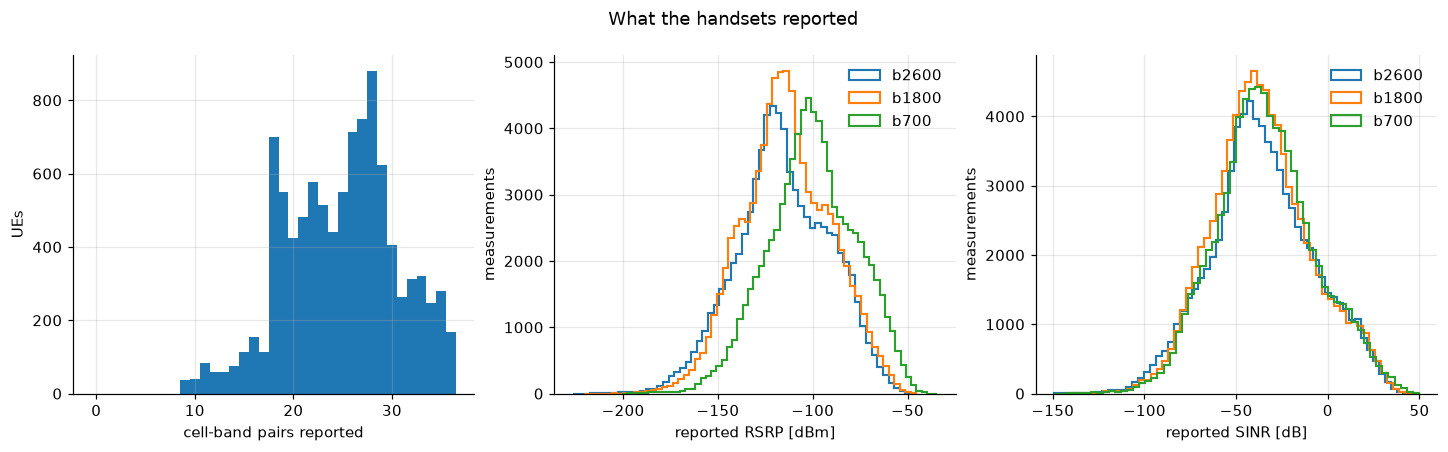

In [20]:
reported = mdt_frame[measurement_columns].notna()

figure, axes = plt.subplots(1, 3, figsize=(16.0, 4.0))
axes[0].hist(reported.sum(axis=1), bins=np.arange(len(measurement_columns) + 2) - 0.5)
axes[0].set_xlabel("cell-band pairs reported")
axes[0].set_ylabel("UEs")
for band in bands:
    for axis, prefix in ((axes[1], "rsrp_"), (axes[2], "sinr_")):
        columns = [
            column
            for column in mdt_frame.columns
            if column.startswith(prefix) and column.endswith(f"_{band}")
        ]
        values = mdt_frame[columns].to_numpy().ravel()
        axis.hist(values[np.isfinite(values)], bins=60, histtype="step", lw=1.4, label=band)
axes[1].set_xlabel("reported RSRP [dBm]")
axes[2].set_xlabel("reported SINR [dB]")
for axis in axes[1:]:
    axis.set_ylabel("measurements")
    axis.legend()
figure.suptitle("What the handsets reported")
save_fig(figure, "mdt_reported_summary")
plt.show()


### The demand map

PRBs each tile needs, per interval, from the UEs served on their reports. The
busiest interval is what a cell has to be dimensioned for; the mean shows where
demand sits on an ordinary hour. Empty tiles are left blank: "nobody here" is a
different statement from "a little demand here".


(168, 61, 74) [t, row, col], peak tile 9756.7 PRBs


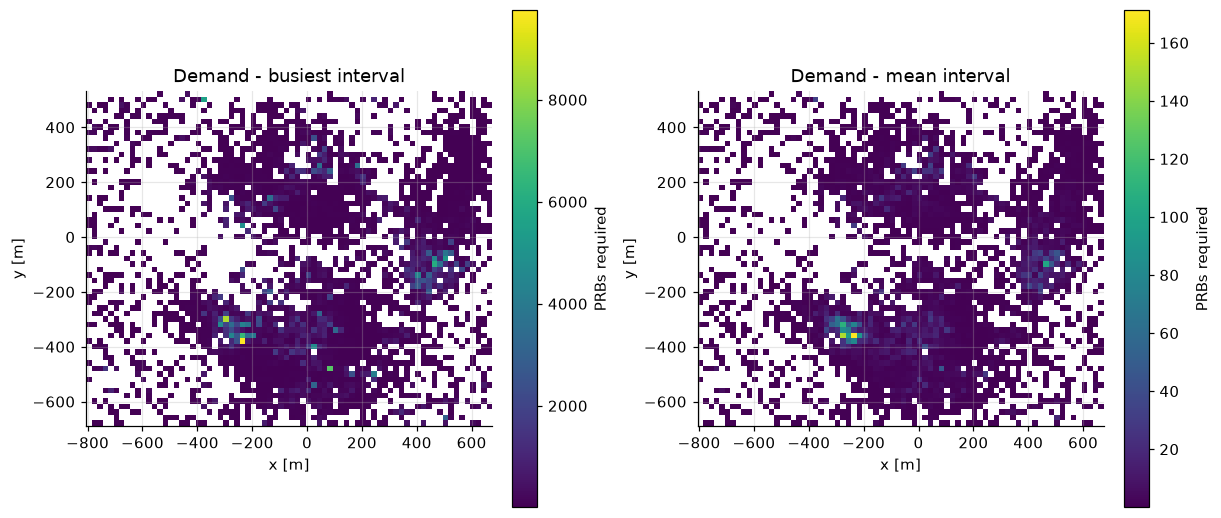

In [21]:
demand_map_file = Path(cfg.simulation.output.demand_map_file)
with np.load(demand_map_file, allow_pickle=False) as archive:
    prb_required = archive["prb_required"]

print(f"{prb_required.shape} [t, row, col], peak tile {prb_required.max():.1f} PRBs")

figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), constrained_layout=True)
for axis, (layer, title) in zip(
    axes,
    [(prb_required.max(axis=0), "busiest interval"), (prb_required.mean(axis=0), "mean interval")],
):
    image = axis.imshow(np.where(layer > 0, layer, np.nan), origin="lower", extent=extent, aspect="equal")
    figure.colorbar(image, ax=axis, label="PRBs required")
    axis.set_title(f"Demand - {title}")
    axis.set_xlabel("x [m]")
    axis.set_ylabel("y [m]")
save_fig(figure, "demand_map")
plt.show()


### The population the reports came from

Cells go in as transmitters and UEs as receivers, on the scene. Every
device is drawn as an area emitter, so the UEs are sampled: the whole table would
be slow to trace and would wash the scene out.

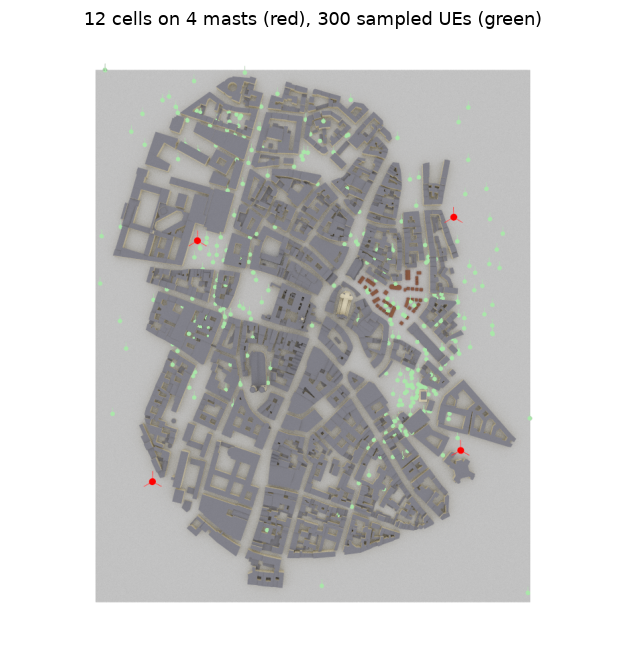

In [22]:
from sionna.rt import Receiver

UE_RENDER_SAMPLE = 300

sample = ue.sample(n=min(UE_RENDER_SAMPLE, len(ue)), random_state=cfg.seed)
n_masts = len({(cell.x, cell.y) for cell in cells})
device_names = [cell.name for cell in cells] + [f"ue{index}" for index in range(len(sample))]
for name in device_names:
    if scene.get(name) is not None:
        scene.remove(name)

transmitter.build(scene, cells, bands[0], float(cfg.simulation.antenna.power_rs))
for index, row in enumerate(sample.itertuples()):
    scene.add(
        Receiver(name=f"ue{index}", position=[row.x, row.y, row.z], display_radius=6.0)
    )

render(
    scene,
    camera,
    f"{len(cells)} cells on {n_masts} masts (red), {len(sample)} sampled UEs (green)",
    name="scene_devices",
    show_devices=True,
    show_orientations=True,
)

## 6. What was written



These five files are the input to `01_eda.ipynb` and to everything downstream.

In [23]:
pd.DataFrame(
    [
        {
            "stage": stage,
            "file": str(path),
            "exists": Path(path).is_file(),
            "size_mb": round(Path(path).stat().st_size / 1e6, 3) if Path(path).is_file() else None,
        }
        for stage, path in [
            ("scenario", ue_file),
            ("scenario", manifest_file),
            ("radio map", radio_map_file),
            ("mdt", mdt_file),
            ("mdt", demand_map_file),
        ]
    ]
)

,stage,file,exists,size_mb
0,scenario,data\external\ue_positions.csv,True,0.455
1,scenario,data\external\scenario.json,True,0.035
2,radio map,data\interim\radio_map.npz,True,0.807
3,mdt,data\interim\mdt.csv,True,4.722
4,mdt,data\interim\demand_map.npz,True,0.064
